In [9]:
import pandas as pd

url="https://docs.google.com/spreadsheets/d/1QnduVFuFBuuzbTDigcy7RVGuy4FF2d-l8gKWOhrLbyg/export?format=csv&gid=0"
#url="https://objectstorage.mx-queretaro-1.oraclecloud.com/p/t19Yz5Ndw4o2nggEJbtJCh24dcNksWToFzAr8v3j_Q5mRnFRCFUD37ZiyK4AZdgf/n/axsuszsnqvkf/b/bucket-hackathon/o/base_de_datosBase%20-%20Hoja%201.csv"

df = pd.read_csv(url)

In [10]:
df.head()

,titulo,texto,categoria
0,Fundamentos de Node.js en el Servidor,Node.js permite crear servidores backend usand...,Backend
1,El Protocolo HTTP en la Web,HTTP es el protocolo que usan los clientes y s...,Backend
2,Principios y Verbos de una API REST,"Una API REST usa verbos como GET, POST, PUT y ...",Backend
3,Ventajas y Configuración de Spring Boot,Spring Boot facilita crear aplicaciones Java a...,Backend
4,Rol del Servidor Backend,Un servidor backend recibe solicitudes y devue...,Backend


#Exploración y limpieza de datos (EDA)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   titulo     320 non-null    object
 1   texto      320 non-null    object
 2   categoria  320 non-null    object
dtypes: object(3)
memory usage: 7.6+ KB


In [12]:
df.columns

Index(['titulo', 'texto', 'categoria'], dtype='object')

##VERIFICANDO DATOS NULOS O VACIOS


In [27]:
df.isnull().sum()

,0
titulo,0
texto,0
categoria,0
Texto_limpio,0


In [14]:

# 1. Verificación
nulos_iniciales = df.isnull().sum().sum()
print(f"Cantidad total de nulos detectados: {nulos_iniciales}")

# 2. Aplicar limpieza si existen nulos en columnas críticas
if nulos_iniciales > 0:
    # Elimina filas donde falte el texto o la categoría
    df = df.dropna(subset=['titulo','texto', 'categoria']).reset_index(drop=True)
    print(f"✅ Nulos eliminados. Tamaño actual del dataset: {df.shape}")
else:
    print("✅ No se encontraron nulos.")

Cantidad total de nulos detectados: 0
✅ No se encontraron nulos.


##VERIFICANDO DUPLICADOS


In [15]:
# Verificar registros duplicados
duplicados = df.duplicated().sum()

print(f"Cantidad total de registros duplicados: {duplicados}")

Cantidad total de registros duplicados: 0


##VERIFICANDO FORMATOS


In [16]:
print(df.dtypes)

titulo       object
texto        object
categoria    object
dtype: object


In [17]:
# Eliminar espacios al inicio y al final
df["titulo"] = df["titulo"].str.strip()
df["texto"] = df["texto"].str.strip()
df["categoria"] = df["categoria"].str.strip()

print(" Espacios eliminados.")

 Espacios eliminados.


In [18]:
#Verificando texto (palabras iguales)
print(df["categoria"].unique())


['Backend' 'Frontend' 'BasesDeDatos' 'IA' 'Cloud' 'Fronted'
 'Bases de datos']


In [19]:
df["categoria"] = df["categoria"].replace({
    "Fronted":"Frontend",
    "Bases de datos":"BasesDeDatos"
})

In [20]:
print(df["categoria"].unique())

['Backend' 'Frontend' 'BasesDeDatos' 'IA' 'Cloud']


##ANALIZANDO VOLUMEN DEL DATASET

In [21]:
print("Dimensiones del dataset:")
print(df.shape)

print(f"\nNúmero de registros: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dimensiones del dataset:
(320, 3)

Número de registros: 320
Número de columnas: 3


In [22]:
#Buscando el balance de categorias
conteo = df["categoria"].value_counts()

print(conteo)

categoria
Cloud           69
BasesDeDatos    66
Backend         63
Frontend        62
IA              60
Name: count, dtype: int64


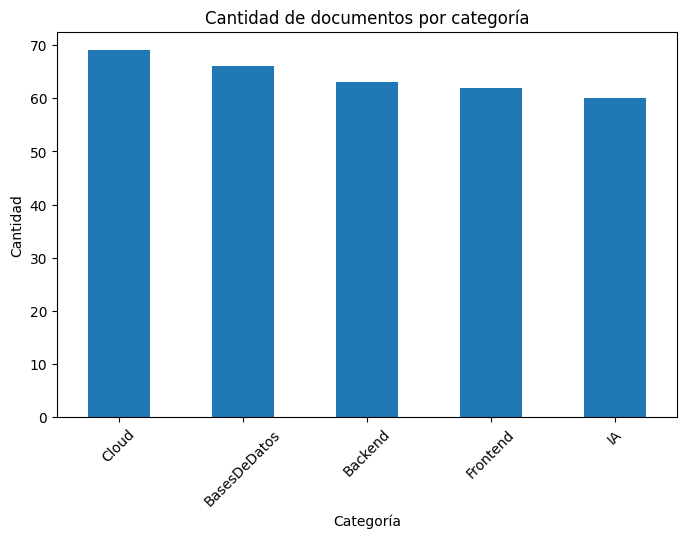

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["categoria"].value_counts().plot(kind="bar")

plt.title("Cantidad de documentos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

plt.show()

#Tratamientos de textos


##CONVERTIR MINUSCULAS


##ELIMINACION DE SIGNOS DE PUNTUACION


In [26]:
#Eliminación de signos en textos

df['texto'] = df['texto'].str.replace(r'[^\w\s]|_', '', regex=True)


,texto,Texto_limpio
0,Node.js permite crear servidores backend usand...,Nodejs permite crear servidores backend usando...
1,HTTP es el protocolo que usan los clientes y s...,HTTP es el protocolo que usan los clientes y s...
2,"Una API REST usa verbos como GET, POST, PUT y ...",Una API REST usa verbos como GET POST PUT y DE...
3,Spring Boot facilita crear aplicaciones Java a...,Spring Boot facilita crear aplicaciones Java a...
4,Un servidor backend recibe solicitudes y devue...,Un servidor backend recibe solicitudes y devue...
